In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer

import warnings
warnings.filterwarnings('ignore')


In [7]:
df = pd.read_csv("/content/drive/MyDrive/IBMZ/dataset_phishing.csv")
df.head()


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


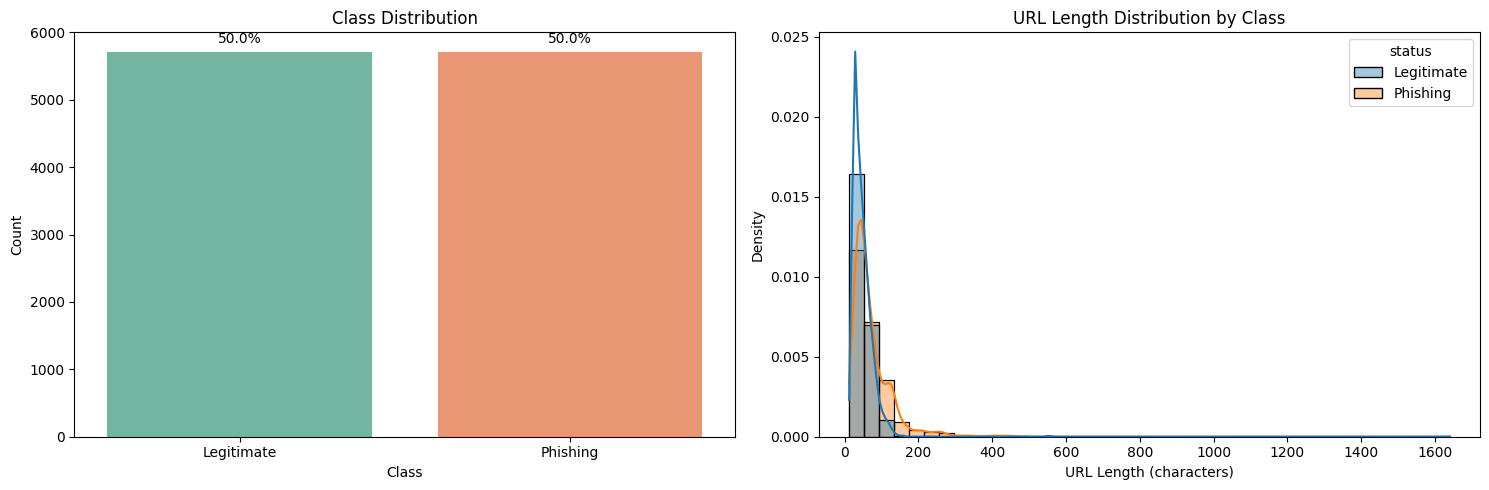

In [8]:
eda_df = df[['url', 'status']].dropna().copy()
eda_df['status'] = eda_df['status'].str.title()
eda_df['url_length'] = eda_df['url'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Class distribution with percentage labels
order = eda_df['status'].value_counts().index
sns.countplot(data=eda_df, x='status', order=order, palette='Set2', ax=axes[0])
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

total = len(eda_df)
for patch in axes[0].patches:
    height = patch.get_height()
    axes[0].annotate(
        f"{(height / total):.1%}",
        (patch.get_x() + patch.get_width() / 2, height),
        ha='center',
        va='bottom',
        fontsize=10,
        xytext=(0, 4),
        textcoords='offset points'
    )

# URL length distribution by class
sns.histplot(
    data=eda_df,
    x='url_length',
    hue='status',
    bins=40,
    kde=True,
    stat='density',
    common_norm=False,
    alpha=0.4,
    ax=axes[1]
    )
axes[1].set_title('URL Length Distribution by Class')
axes[1].set_xlabel('URL Length (characters)')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

In [9]:
df.dropna(inplace=True, subset = ['url','status'])
df['type'] = df['status'].str.lower()
df['type'] = df['type'].map({'legitimate': 0, 'phishing': 1})

X = df['url']
y = df['type']

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,
    analyzer='char_wb',  # character n-grams capture URL patterns well
    ngram_range=(3, 5)
)

X_tfidf = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)


In [10]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("🔹 Logistic Regression Results 🔹")
print(classification_report(y_test, y_pred_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))


🔹 Logistic Regression Results 🔹
              precision    recall  f1-score   support

           0       0.90      0.91      0.91      1157
           1       0.91      0.90      0.91      1129

    accuracy                           0.91      2286
   macro avg       0.91      0.91      0.91      2286
weighted avg       0.91      0.91      0.91      2286

Accuracy: 0.9068241469816273


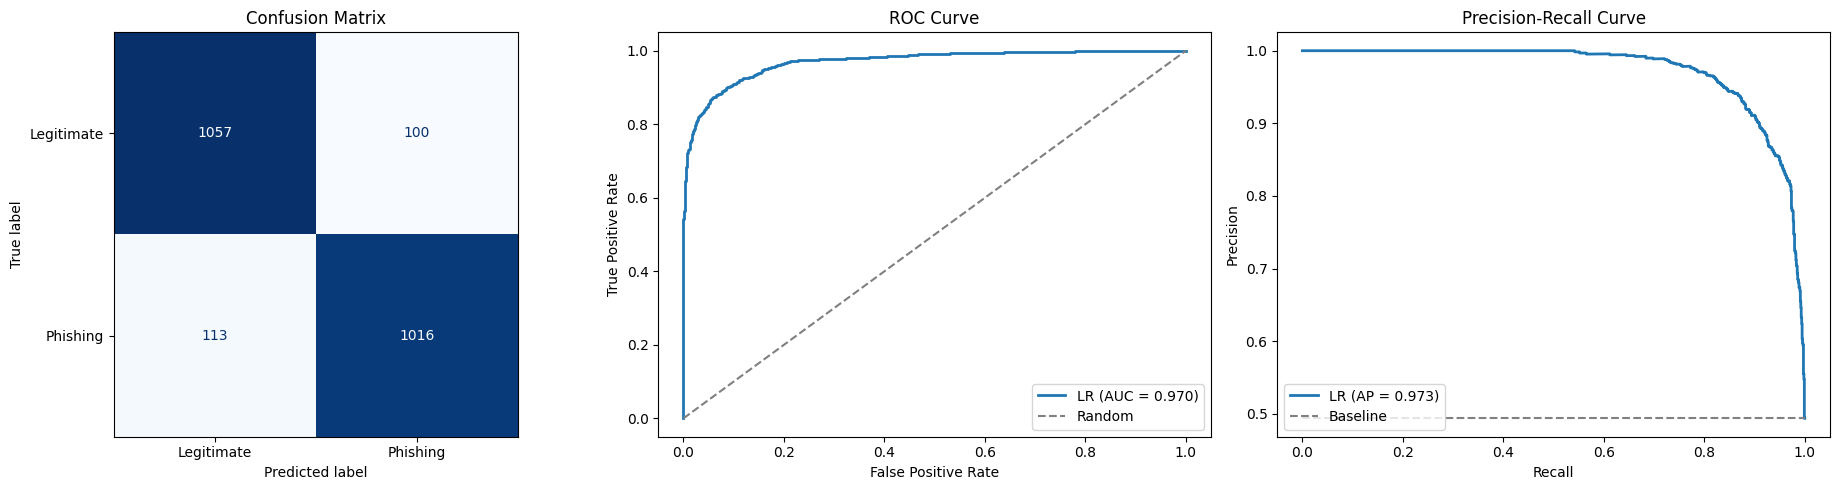

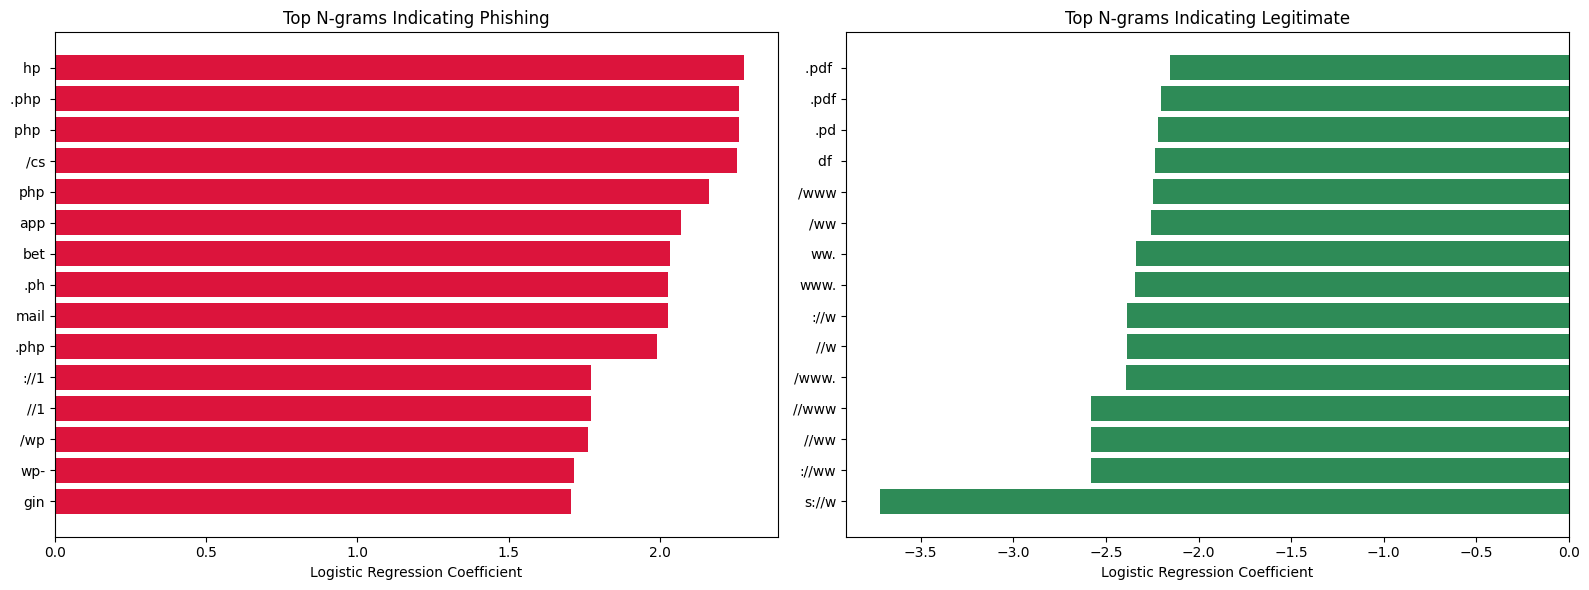

In [11]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
    )

y_proba_lr = lr.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# 1) Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    display_labels=['Legitimate', 'Phishing'],
    cmap='Blues',
    colorbar=False,
    ax=axes[0]
    )
axes[0].set_title('Confusion Matrix')

# 2) ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba_lr)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, lw=2, label=f'LR (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], '--', color='gray', label='Random')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

# 3) Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_proba_lr)
avg_precision = average_precision_score(y_test, y_proba_lr)
baseline = y_test.mean()
axes[2].plot(recall, precision, lw=2, label=f'LR (AP = {avg_precision:.3f})')
axes[2].hlines(baseline, 0, 1, colors='gray', linestyles='--', label='Baseline')
axes[2].set_title('Precision-Recall Curve')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend(loc='lower left')

plt.tight_layout()
plt.show()

# Top character n-grams influencing prediction
feature_names = np.array(vectorizer.get_feature_names_out())
coefficients = lr.coef_[0]
top_n = 15

top_pos_idx = np.argsort(coefficients)[-top_n:]
top_neg_idx = np.argsort(coefficients)[:top_n]

pos_features = feature_names[top_pos_idx]
neg_features = feature_names[top_neg_idx]
pos_values = coefficients[top_pos_idx]
neg_values = coefficients[top_neg_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(pos_features, pos_values, color='crimson')
axes[0].set_title('Top N-grams Indicating Phishing')
axes[0].set_xlabel('Logistic Regression Coefficient')

axes[1].barh(neg_features, neg_values, color='seagreen')
axes[1].set_title('Top N-grams Indicating Legitimate')
axes[1].set_xlabel('Logistic Regression Coefficient')

plt.tight_layout()
plt.show()

Test dataset shape: (504932, 2)
Label distribution in test dataset:
type
0    345738
1    159194
Name: count, dtype: int64
🔹 Test Performance on New Dataset 🔹
              precision    recall  f1-score   support

           0       0.94      0.98      0.96    345738
           1       0.96      0.86      0.91    159194

    accuracy                           0.94    504932
   macro avg       0.95      0.92      0.93    504932
weighted avg       0.95      0.94      0.94    504932

Accuracy: 0.9445747150111302


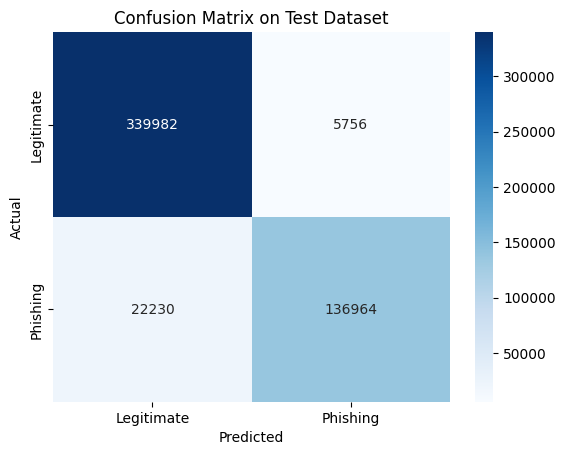

In [13]:
import pandas as pd

# Load test dataset
test_df = pd.read_csv("/content/drive/MyDrive/IBMZ/combined_urls_clean.csv")

# Use only 'url' and 'status'
test_df = test_df[['url', 'type']].dropna()

print("Test dataset shape:", test_df.shape)
test_df.head()

X_test_urls = test_df['url']
y_test = test_df['type'].str.lower().map({'legitimate': 0, 'phishing': 1})

print("Label distribution in test dataset:")
print(y_test.value_counts())

# Use the same vectorizer that was used for training
X_test_tfidf = vectorizer.transform(X_test_urls)  # NOTE: .transform(), NOT .fit_transform()

# Predict with trained model
y_pred_test = lr.predict(X_test_tfidf)

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("🔹 Test Performance on New Dataset 🔹")
print(classification_report(y_test, y_pred_test))
print("Accuracy:", accuracy_score(y_test, y_pred_test))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legitimate','Phishing'], yticklabels=['Legitimate','Phishing'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix on Test Dataset')
plt.show()


In [14]:
import joblib
joblib.dump(lr, '/content/drive/MyDrive/IBMZ/url_classifier_lr_model.pkl')

['/content/drive/MyDrive/IBMZ/url_classifier_lr_model.pkl']

In [15]:
vectorizer_path = '/content/drive/MyDrive/IBMZ/url_vectorizer.pkl'
joblib.dump(vectorizer, vectorizer_path)

print(f" Vectorizer saved at: {vectorizer_path}")


 Vectorizer saved at: /content/drive/MyDrive/IBMZ/url_vectorizer.pkl
